# Lindsay Foster Notebook with New Data
# P2: Text Preprocessing of the British Library

- Author: [Lindsay Foster](https://github.com/LFoster03)
- Repository: [nlp-02-text-preprocessing](https://github.com/LFoster03/nlp-02-text-preprocessing/)
- Purpose: Demonstrate text pre-processing with new data
- Date: 2026-03

## Section 1. Setup and Imports

Imports and configuration appear once, at the top.

WHY:
- Keeps notebooks readable and reproducible
- Mirrors professional scripts
- Makes requirements clear

This is a Markdown cell.

In [14]:
# Section 1 Python cell.

# Imports at the top of the file
# REQ: External packages must be defined in pyproject.toml
# REQ: External packages must be installed in the environment using `uv sync` command
# REQ: External packages used in this notebook must be imported here

from pathlib import Path
import re

import matplotlib.pyplot as plt
import polars as pl

print("Imports complete.")

Imports complete.


## Section 2. Read the Text Data

This is a Markdown cell.

In [15]:
# Section 2 Python cell

# In notebooks, start with the current working directory
# where the notebook is located.
NOTEBOOKS_PATH: Path = Path.cwd()
ROOT_PATH: Path = NOTEBOOKS_PATH.parent

DATA_PATH: Path = ROOT_PATH / "data"
NOTEBOOKS_PATH: Path = ROOT_PATH / "notebooks"
SCRIPTS_PATH: Path = ROOT_PATH / "scripts"

# Choose a text file to analyze.
# Each line is treated as one text record.
input_path: Path = (
    DATA_PATH
    / "C:\\Repos\\nlp-02-text-preprocessing\\data copy\\new_data_text_foster.txt"
)

# Read all lines from the file.
text_list: list[str] = input_path.read_text(encoding="utf-8").splitlines()

# Remove blank lines.
text_list = [line.strip() for line in text_list if line.strip()]

print("Data loaded successfully.")
print(f"Loaded {len(text_list):,} text records.")

# Combine all text rows into one large string for simple preprocessing.
raw_text: str = " ".join(text_list)

print(f"Raw text length: {len(raw_text):,} characters")
print("First 500 characters of raw text:")
print(raw_text[:500])

Data loaded successfully.
Loaded 7 text records.
Raw text length: 1,098 characters
First 500 characters of raw text:
The British Library is the national library of the United Kingdom. Based in London, it is one of the largest libraries in the world, with an estimated collection of over 200 million items from multiple countries. As a legal deposit library, it receives copies of all books produced in the United Kingdom and Ireland, as well as a significant proportion of overseas titles distributed in the United Kingdom. The library operates as a non-departmental public body sponsored by the Department for Cultur


## Section 3. Inspect the Raw Text

This is a Markdown cell.

In [16]:
# Section 3 Python cell

# Review the text records before preprocessing.
# This helps confirm the data loaded correctly and gives a
# sense of the structure of the text.

print("First 5 text records:")
for line in text_list[:5]:
    print("-", line)

print(f"\nLoaded {len(text_list):,} text records.")
print(f"Raw text length: {len(raw_text):,} characters")

print("\nFirst 500 characters of combined text:")
print(raw_text[:500])

First 5 text records:
- The British Library is the national library of the United Kingdom.
- Based in London, it is one of the largest libraries in the world, with an estimated collection of over 200 million items from multiple countries.
- As a legal deposit library, it receives copies of all books produced in the United Kingdom and Ireland, as well as a significant proportion of overseas titles distributed in the United Kingdom.
- The library operates as a non-departmental public body sponsored by the Department for Culture, Media and Sport.
- The British Library is a major research library, with items in many languages and in many formats, both print and digital: books, manuscripts, journals, newspapers, magazines, sound and music recordings, videos, play-scripts, patents, databases, maps, stamps, prints, drawings.

Loaded 7 text records.
Raw text length: 1,098 characters

First 500 characters of combined text:
The British Library is the national library of the United Kingdom. Based

## Section 4. Tokenize the Raw Text

This is a Markdown cell.

In [17]:
# Section 4 Python cell

# Split the raw text into rough word-like pieces using whitespace.
raw_tokens: list[str] = raw_text.split()
count_of_raw_tokens: int = len(raw_tokens)

print("First 20 raw tokens:")
print(raw_tokens[:20])
print(f"Total raw tokens: {count_of_raw_tokens:,}")

First 20 raw tokens:
['The', 'British', 'Library', 'is', 'the', 'national', 'library', 'of', 'the', 'United', 'Kingdom.', 'Based', 'in', 'London,', 'it', 'is', 'one', 'of', 'the', 'largest']
Total raw tokens: 171


## Section 5. Normalize the Text

This is a Markdown cell.

In [18]:
# Section 5 Python cell

# Convert all text to lowercase so words like "Data" and "data"
# are treated as the same token.
lower_text: str = raw_text.lower()

print("First 500 characters of lowercase text:")
print(lower_text[:500])

First 500 characters of lowercase text:
the british library is the national library of the united kingdom. based in london, it is one of the largest libraries in the world, with an estimated collection of over 200 million items from multiple countries. as a legal deposit library, it receives copies of all books produced in the united kingdom and ireland, as well as a significant proportion of overseas titles distributed in the united kingdom. the library operates as a non-departmental public body sponsored by the department for cultur


## Section 6. Remove Punctuation and Tokenize Again


This is a Markdown cell.

In [19]:
# Section 6 Python cell

# Replace any character that is not a letter, number, or whitespace
# with a space. This removes punctuation and many special characters.
no_punct_text: str = re.sub(r"[^a-z0-9\s]", " ", lower_text)

# Tokenize again after punctuation removal.
tokens_no_punct: list[str] = no_punct_text.split()
count_of_tokens_no_punct: int = len(tokens_no_punct)

print("First 20 tokens after lowercasing and punctuation removal:")
print(tokens_no_punct[:20])
print(f"Total tokens after punctuation removal: {count_of_tokens_no_punct:,}")

First 20 tokens after lowercasing and punctuation removal:
['the', 'british', 'library', 'is', 'the', 'national', 'library', 'of', 'the', 'united', 'kingdom', 'based', 'in', 'london', 'it', 'is', 'one', 'of', 'the', 'largest']
Total tokens after punctuation removal: 175


## Section 7. Remove Stop Words


This is a Markdown cell.

In [20]:
# Section 7 Python cell

# Stop words are very common words that often add little meaning
# for simple frequency analysis.
STOP_WORDS: set[str] = {
    "a",
    "an",
    "and",
    "are",
    "as",
    "at",
    "be",
    "but",
    "by",
    "for",
    "from",
    "has",
    "have",
    "in",
    "is",
    "it",
    "its",
    "of",
    "on",
    "or",
    "that",
    "the",
    "to",
    "was",
    "were",
    "will",
    "with",
}

# Keep only tokens that:
# - are longer than 2 characters
# - are not in the stop word list
clean_tokens: list[str] = [
    token for token in tokens_no_punct if len(token) > 2 and token not in STOP_WORDS
]

count_of_clean_tokens: int = len(clean_tokens)

print("First 20 cleaned tokens:")
print(clean_tokens[:20])
print(f"Total cleaned tokens: {count_of_clean_tokens:,}")

First 20 cleaned tokens:
['british', 'library', 'national', 'library', 'united', 'kingdom', 'based', 'london', 'one', 'largest', 'libraries', 'world', 'estimated', 'collection', 'over', '200', 'million', 'items', 'multiple', 'countries']
Total cleaned tokens: 112


## Section 7.5: Compute Average Token Length & Token Reduction

In this section, we add additional analytical metrics to better understand the effects of preprocessing.

- **Average Token Length:** Measures the average number of characters per cleaned token. This helps assess the complexity of the vocabulary.
- **Token Reduction:** Calculates how many tokens were removed during preprocessing, providing insight into how much noise (e.g., punctuation, stopwords) was eliminated.

These metrics improve interpretability by quantifying both the structure and impact of preprocessing.

In [21]:
# Section 7.5 Python cell

# Average token length
avg_token_length = sum(len(token) for token in clean_tokens) / len(clean_tokens)

print(f"Average cleaned token length: {avg_token_length:.2f} characters")

# Token reduction
tokens_removed = count_of_raw_tokens - count_of_clean_tokens
reduction_percent = (tokens_removed / count_of_raw_tokens) * 100

print(f"Tokens removed during preprocessing: {tokens_removed:,}")
print(f"Percentage reduction: {reduction_percent:.2f}%")

Average cleaned token length: 6.67 characters
Tokens removed during preprocessing: 59
Percentage reduction: 34.50%


## Section 8. Build a Before/After Summary Table


This is a Markdown cell.

In [22]:
# Section 8 Python cell

summary_df: pl.DataFrame = pl.DataFrame(
    {
        "stage": [
            "raw tokens",
            "after punctuation removal",
            "after stop word removal",
        ],
        "count": [
            count_of_raw_tokens,
            count_of_tokens_no_punct,
            count_of_clean_tokens,
        ],
    }
)

print("Preprocessing summary:")
print(summary_df)

Preprocessing summary:
shape: (3, 2)
┌───────────────────────────┬───────┐
│ stage                     ┆ count │
│ ---                       ┆ ---   │
│ str                       ┆ i64   │
╞═══════════════════════════╪═══════╡
│ raw tokens                ┆ 171   │
│ after punctuation removal ┆ 175   │
│ after stop word removal   ┆ 112   │
└───────────────────────────┴───────┘


## Section 9. Build a Frequency Table with Polars

This is a Markdown cell.

In [23]:
# Section 9 Python cell

# Create a Polars DataFrame with one row per cleaned token.
token_df: pl.DataFrame = pl.DataFrame({"token": clean_tokens})

# Group by token, count occurrences, and sort from most common to least common.
freq_df: pl.DataFrame = token_df.group_by("token").len().sort("len", descending=True)

print("Top 20 most frequent cleaned tokens:")
print(freq_df.head(20))

Top 20 most frequent cleaned tokens:
shape: (20, 2)
┌─────────────┬─────┐
│ token       ┆ len │
│ ---         ┆ --- │
│ str         ┆ u64 │
╞═════════════╪═════╡
│ library     ┆ 8   │
│ items       ┆ 4   │
│ million     ┆ 3   │
│ books       ┆ 3   │
│ kingdom     ┆ 3   │
│ …           ┆ …   │
│ new         ┆ 1   │
│ patents     ┆ 1   │
│ well        ┆ 1   │
│ deposit     ┆ 1   │
│ significant ┆ 1   │
└─────────────┴─────┘


## Section 10. Build a "Most Frequent Cleaned Tokens" Bar Chart


This is a Markdown cell.

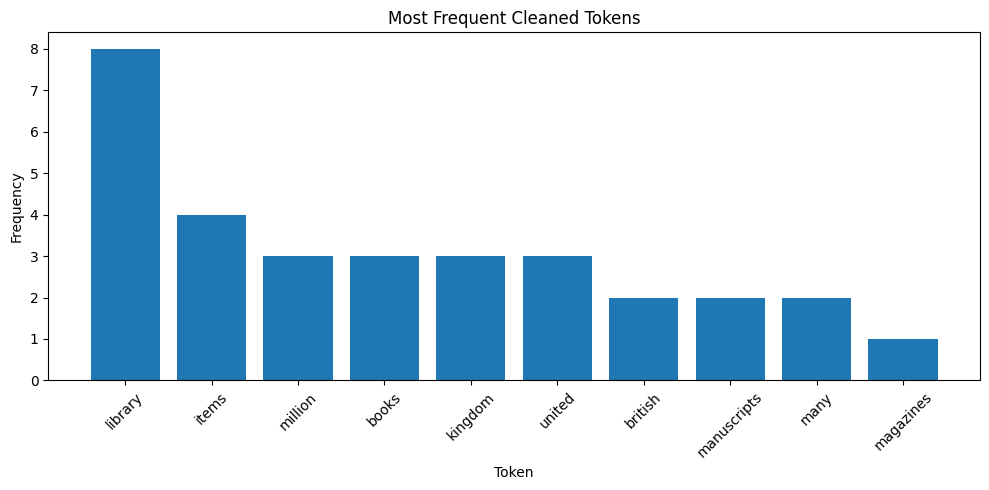

In [24]:
# Section 10 Python cell

top_df: pl.DataFrame = freq_df.head(10)

plt.figure(figsize=(10, 5))
plt.bar(top_df["token"], top_df["len"])

ax = plt.gca()
ax.tick_params(axis="x", labelrotation=45)

plt.title("Most Frequent Cleaned Tokens")
plt.xlabel("Token")
plt.ylabel("Frequency")
plt.tight_layout()
plt.show()

## Section 11. Compare Raw vs Clean Token Counts


This is a Markdown cell.

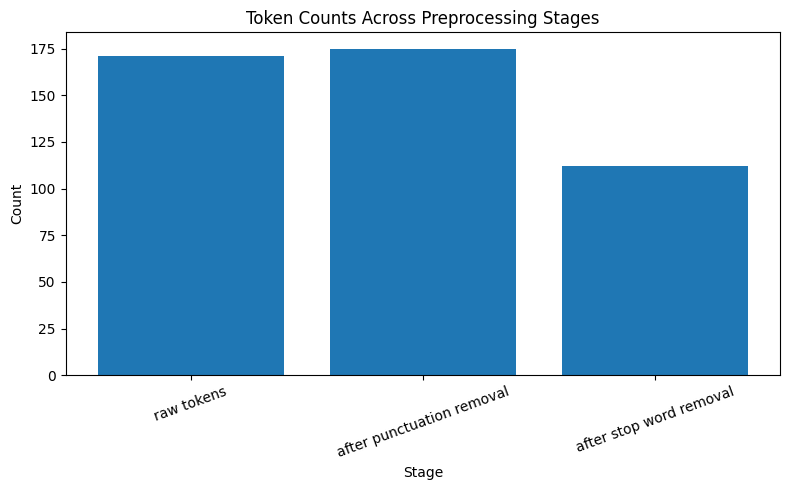

In [25]:
# Section 11 Python cell

plt.figure(figsize=(8, 5))
plt.bar(summary_df["stage"], summary_df["count"])

ax = plt.gca()
ax.tick_params(axis="x", labelrotation=20)

plt.title("Token Counts Across Preprocessing Stages")
plt.xlabel("Stage")
plt.ylabel("Count")
plt.tight_layout()
plt.show()

## Section 12: Token Length Distribution (New Visualization)

This section introduces a histogram to visualize the distribution of token lengths after preprocessing.

- Each bar represents the frequency of tokens with a specific number of characters.
- This visualization complements the average token length by showing the full distribution rather than a single summary value.

This helps identify whether the text consists mostly of short, simple words or longer, more complex vocabulary.

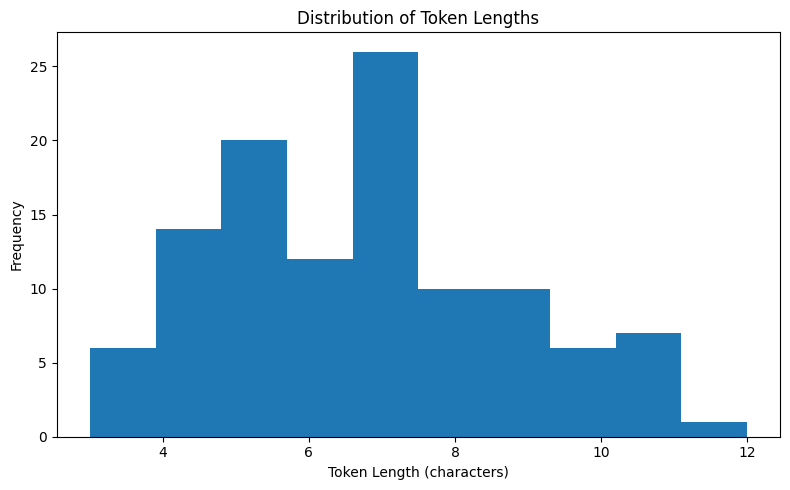

In [26]:
# Section 12 Python cell

# Compute token lengths
token_lengths = [len(token) for token in clean_tokens]

# Create histogram
plt.figure(figsize=(8, 5))
plt.hist(token_lengths, bins=10)

plt.title("Distribution of Token Lengths")
plt.xlabel("Token Length (characters)")
plt.ylabel("Frequency")
plt.tight_layout()
plt.show()

## Reminder: "Run All" before sending to GitHub

Before saving a notebook (and running git add-commit-push),
**click 'Run All'** to generate all outputs and display them in the notebook. 

After git add-commit-push, **verify your notebook appears** in your GitHub repo. 

This is a Markdown cell.
